# Task 4 — Classifier Comparison: TF-IDF Baseline vs BERT+LoRA
**AIML339 Email Thread Triage**

This notebook compares the two classifiers on the BC3 test set (37 emails, 6 threads).
Both models were evaluated on the same split and the same 6 multi-label categories.

Predictions are loaded from:
- `results/bc3_baseline_test_predictions.csv` (TF-IDF + OneVsRestClassifier)
- `results/bc3_bert_lora_test_predictions.csv` (bert-base-uncased + LoRA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, hamming_loss

LABEL_NAMES = ["Request", "Propose", "Commit", "Meeting", "Subjective", "Informative"]

baseline = pd.read_csv("../results/bc3_baseline_test_predictions.csv")
bert     = pd.read_csv("../results/bc3_bert_lora_test_predictions.csv")

# Build true and pred matrices for each model
y_true     = baseline[[f"true_{l}" for l in LABEL_NAMES]].values
y_baseline = baseline[[f"pred_{l}" for l in LABEL_NAMES]].values
y_bert     = bert[[f"pred_{l}" for l in LABEL_NAMES]].values

print(f"Test emails: {len(y_true)}")

Test emails: 37


## Overall metrics

In [2]:
def overall_metrics(y_true, y_pred, name):
    return {
        "Model":        name,
        "Micro F1":     round(f1_score(y_true, y_pred, average="micro", zero_division=0), 3),
        "Macro F1":     round(f1_score(y_true, y_pred, average="macro", zero_division=0), 3),
        "Precision":    round(precision_score(y_true, y_pred, average="micro", zero_division=0), 3),
        "Recall":       round(recall_score(y_true, y_pred, average="micro", zero_division=0), 3),
        "Hamming loss": round(hamming_loss(y_true, y_pred), 3),
    }

summary = pd.DataFrame([
    overall_metrics(y_true, y_baseline, "TF-IDF baseline"),
    overall_metrics(y_true, y_bert,     "BERT + LoRA"),
]).set_index("Model")

print(summary.to_string())

                 Micro F1  Macro F1  Precision  Recall  Hamming loss
Model                                                               
TF-IDF baseline     0.560     0.410      0.563   0.557         0.347
BERT + LoRA         0.637     0.525      0.522   0.818         0.369


## Per-label F1

In [3]:
f1_baseline = f1_score(y_true, y_baseline, average=None, zero_division=0)
f1_bert     = f1_score(y_true, y_bert,     average=None, zero_division=0)

per_label = pd.DataFrame({
    "Label":           LABEL_NAMES,
    "TF-IDF baseline": f1_baseline.round(3),
    "BERT + LoRA":     f1_bert.round(3),
    "Delta":           (f1_bert - f1_baseline).round(3),
}).set_index("Label")

print(per_label.to_string())

             TF-IDF baseline  BERT + LoRA  Delta
Label                                           
Request                0.412        0.605  0.193
Propose                0.154        0.513  0.359
Commit                 0.400        0.600  0.200
Meeting                0.640        0.595 -0.045
Subjective             0.857        0.839 -0.018
Informative            0.000        0.000  0.000


## Per-label F1 bar chart

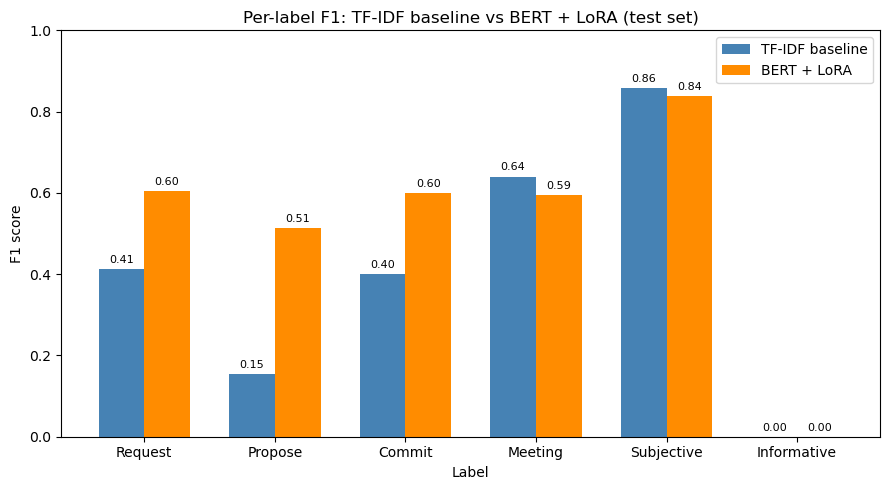

Saved: results/bc3_comparison_f1.png


In [4]:
x     = np.arange(len(LABEL_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, f1_baseline, width, label="TF-IDF baseline", color="steelblue")
bars2 = ax.bar(x + width/2, f1_bert,     width, label="BERT + LoRA",     color="darkorange")

ax.set_xlabel("Label")
ax.set_ylabel("F1 score")
ax.set_title("Per-label F1: TF-IDF baseline vs BERT + LoRA (test set)")
ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES)
ax.set_ylim(0, 1.0)
ax.legend()
ax.bar_label(bars1, fmt="%.2f", padding=3, fontsize=8)
ax.bar_label(bars2, fmt="%.2f", padding=3, fontsize=8)

plt.tight_layout()
plt.savefig("../results/bc3_comparison_f1.png", dpi=150)
plt.show()
print("Saved: results/bc3_comparison_f1.png")